<a href="https://colab.research.google.com/github/MichelLLIUU/Hands-on-ML-with-Pytorch/blob/main/3_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

sklearn.datasets 软件包 主要包含三类函数：fetch_* 函数（如fetch_openml() ），用于下载现实生活中的数据集；load_* 函数，用于加载与 Scikit-Learn 绑定的小型玩具数据集（因此无需通过互联网下载）；make_* 函数，用于生成假数据集，对测试非常有用。生成的数据集通常以(X, y) 元组的形式返回，其中包含输入数据和目标数据，两者都是 NumPy 数组。其他数据集以sklearn.utils.Bunch 对象的形式返回 ，这是一个字典，其条目也可作为属性访问。它们通常包含以下条目：

"DESCR"
数据集描述

"data"
输入数据，通常为二维 NumPy 数组

"target"
标签，通常为一维 NumPy 数组

fetch_openml() 函数有点不同寻常，因为默认情况下，它以 Pandas DataFrame 的形式返回输入，以 Pandas Series 的形式返回标签（除非数据集很稀疏）。但 MNIST 数据集包含图像，而 DataFrames 并不适合图像，因此最好设置as_frame=False ，以 NumPy 数组的形式获取数据。

In [2]:
X, y = mnist.data, mnist.target

In [5]:
X
X.shape


(70000, 784)

In [4]:
y
y.shape

(70000,)

共有 70,000 张图像，每张图像有 784 个特征。这是因为每幅图像都是 28 × 28 像素，每个特征只代表一个像素的强度，从 0（白色）到 255（黑色）。让我们来看看数据集中的一个数字（图 3-1）。我们需要做的就是抓取一个实例的特征向量，将其重塑为一个 28 × 28 的数组，然后使用 Matplotlib 的imshow() 函数显示出来。我们使用cmap="binary" 获得灰度颜色图，其中 0 代表白色，255 代表黑色：

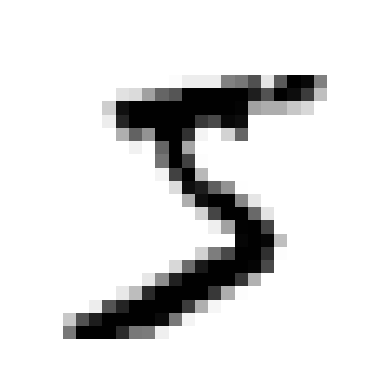

In [6]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [7]:
y[0]

'5'

为了让大家感受分类任务的复杂性，图 3-2展示了 MNIST 数据集中的几张图片。这里的数字形状种类繁多。尽管如此，这些图像干净整洁、居中、没有过度旋转，而且所有数字的大小大致相同：这个数据集不需要太多预处理（现实世界的数据集通常没那么友好）。

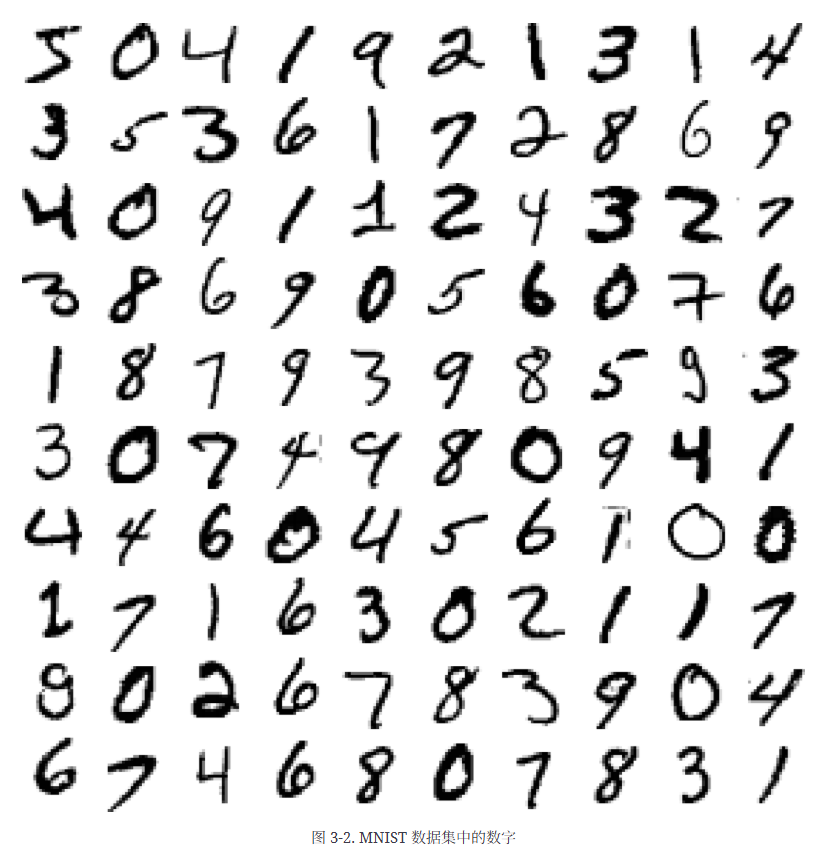

In [8]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

此外，有些学习算法对训练实例的顺序很敏感，如果连续获得很多相似实例，它们的性能就会很差。 数据集的洗牌可以确保这种情况不会发生 。

# 训练二进制分类器

现在，让 来简化问题，只尝试识别一个数字--例如数字 5。这个 "5-检测器 "将是二进制分类器的一个例子，能够区分 5 和非 5 这两个类别。首先，我们将为这项分类任务创建目标向量：

现在，让我们选择一个分类器并对其进行训练。一个好的开始是使用随机梯度下降（SGD，或随机 GD）分类器，使用 Scikit-Learn 的SGDClassifier 类。这种分类器能够高效处理超大数据集。部分原因是 SGD 能够一次一个地独立处理训练实例，这也使得 SGD 非常适合在线学习，稍后您将看到这一点。让我们创建一个SGDClassifier ，并在整个训练集上对它进行训练：

In [9]:
y_train_5 = (y_train == '5')  # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [10]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [11]:
sgd_clf.predict([some_digit])

array([ True])

# 性能评估

评估分类器 通常比评估回归器要棘手得多，因此本章我们将用大量篇幅来讨论这一主题。有很多性能指标可供使用，所以再拿一杯咖啡，准备学习一堆新概念和缩略语吧！

# 使用交叉验证衡量准确性
评估模型的好方法是使用交叉验证，就像在第 2 章中所做的那样。让我们使用cross_val_score() 函数 来评估我们的SGDClassifier 模型，使用三次k 倍交叉验证。请记住，k-fold 交叉验证意味着将训练集分成k 个折叠 （在本例中是三个），然后训练模型k次，每次取出一个不同的折叠进行评估（参见第 2 章） ：

In [12]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

也可以手写交叉验证

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is
                                       # not already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))  # prints 0.95035, 0.96035, and 0.9604

没错，它的准确率超过 90%！这是因为只有大约 10% 的图片是 5，所以如果你总是猜测图片不是5，你就会有大约 90% 的时间是正确的。比诺斯特拉达穆斯还准。

这就说明了为什么**准确率通常不是衡量分类器性能的首选标准**，尤其是在处理偏斜数据集时 （即
某些类别的出现频率远高于其他类别）。评估分类
器性能的更好方法是查看混淆矩阵(CM)。

# **混淆矩阵**
混淆矩阵的一般概念是计算在所有 A/B 对中，A 类实例被分类为 B 类的次数。例如，要知道分类器将 8 和 0 的图像混淆的次数，可以查看混淆矩阵的第 8 行第 0 列。

要计算混淆矩阵，首先需要有一组预测结果，以便与实际目标进行比较。您可以在测试集上进行预测，但最好暂时不要使用测试集**（请记住，只有在项目的最后阶段，当分类器准备好启动时，您才希望使用测试集）**。相反，您可以使用cross_val_predict() 函数 ：

In [13]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [15]:
y_train_pred

array([ True, False, False, ...,  True, False, False])

与cross_val_score() 函数一样，cross_val_predict() 也会执行k 折交叉验证，但它返回的不是评估分数，而是每个测试折上的预测结果。这意味着，您将获得训练集中每个实例的准确预测（我所说的 "准确 "是指 "样本外"：模型对训练期间从未见过的数据进行预测）。

现在可以使用confusion_matrix() 函数获取混淆矩阵了。只需将目标类别 (y_train_5) 和预测类别 (y_train_pred) 传递给它即可：

In [14]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

混淆矩阵中的每一行代表一个实际类别 ，而每一列代表一个预测类别。 矩阵的第一行是非 5 图像（负类）： 其中 53 892 张图片被正确分类为非 5 类图片（称为真阴性图片）， ，而其余 687 张图片被错误分类为 5 类图片（假阳性图片 ，也称为I 类错误）。 第二行考虑的是 5s（阳性类）图像： 1,891 张被错误地分类为非 5s（假阴性 ，也称为II 类错误）， ，而其余 3,530 张被正确地分类为 5s（真阳性）。 一个完美的分类器只有真阳性和真阴性，因此其混淆矩阵只有在主对角线上（从左上角到右下角）才有非零值：

>>> y_train_perfect_predictions = y_train_5  # pretend we reached perfection
>>> confusion_matrix(y_train_5, y_train_perfect_predictions)
array([[54579,     0],
       [    0,  5421]])

# 混淆矩阵提供了大量信息，但有时您可能更喜欢更简洁的指标。一个有趣的指标是正向预测的准确度；这被称为分类器的精度（公式 3-1）。

# 等式 3-1. 精确度

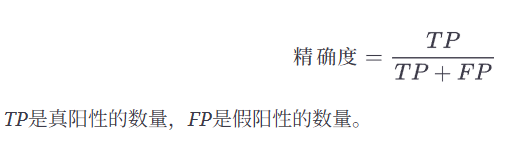

现在考虑一个模型，它只有在非常自信的情况下才会做出正面预测。让我们把它推向极端，假设它总是做出负面预测，除了对它最有信心的实例做出一次正面预测。如果这一次预测是正确的，那么分类器的精度就是 100%（精度 = 1/1 = 100%） 。显然，这样的分类器用处不大，因为它会忽略除了一个正向实例之外的所有实例。因此，精度通常与另一个名为召回 率的指标一起使用， ，也称为灵敏度 或真阳性率（TPR）： ，这是分类器正确检测到的阳性实例的比率（等式 3-2）。

# 等式 3-2. 召回率
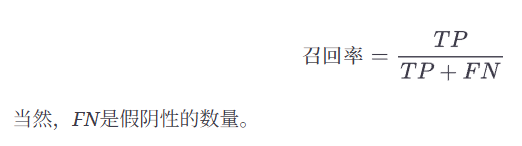

In [17]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [18]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

# 当它声称一张图片代表 5 时，正确率只有 83.7%。而且，它只能检测到 65.1% 的 5。

1分数是精确度和召回率的调和平均值 （等式 3-**3）。常规均值对所有值一视同仁，而调和均值对低值的权重要大得多。因此，分类器只有在召回率和精确率都很高的情况下才能获得较高的F1分数。**

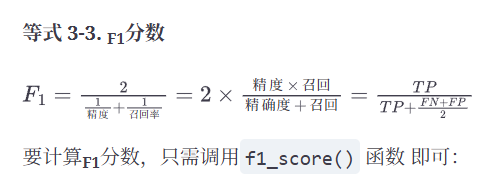

In [19]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

F1分数偏向于精确度和召回率相近的分类器。这并不总是你想要的：在某些情况下，你主要关心的是精度，而在其他情况下，你真正关心的是召回率。例如，如果你训练了一个分类器来检测对儿童安全的视频，那么你可能会更喜欢一个剔除了许多好视频（召回率低）但只保留安全视频（高精度）的分类器，而不是一个召回率高得多但却让一些非常糟糕的视频出现在你的产品中的分类器（在这种情况下，你甚至可能想要添加一个人工管道来检查分类器的视频选择）。另一方面，假设您训练了一个分类器来检测监控图像中的偷窃者：只要您的分类器的召回率达到 99%，即使精确度只有 30%，也没有问题。当然，保安会收到一些错误警报，但几乎所有的偷窃者都会被抓住。同样，医疗诊断通常需要较高的召回率，以避免遗漏重要信息。误报可以通过后续医疗检查排除。

不幸的是，鱼与熊掌不可兼得：提高精确度会降低召回率，反之亦然。这就是所谓的精度/召回权衡。

# 精确度/召回权衡
要理解这种权衡，让我们来看看SGDClassifier 是如何做出分类决策的。对于每个实例，它都会根据决策函数 计算出一个分数。如果得分大于阈值 ，它就会将实例归入正分类；反之，则归入负分类。图 3-4显示了从左侧最低分到右侧最高分的几个数字。假设判定阈值位于中心箭头处（两个 5 之间）：在该阈值的右侧会发现 4 个真阳性（实际为 5），1 个假阳性（实际为 6）。因此，在该阈值下，精确度为 80%（5 个中有 4 个）。但在 6 个实际 5 中，分类器只检测到 4 个，因此召回率为 67%（6 个中有 4 个）。如果提高阈值（将其移动到右侧箭头处），假阳性（6）就会变成真阴性，从而提高精确度（在本例中可达 100%），但一个真阳性就会变成假阴性，使召回率下降到 50%。相反，降低阈值会增加召回率，降低精度。

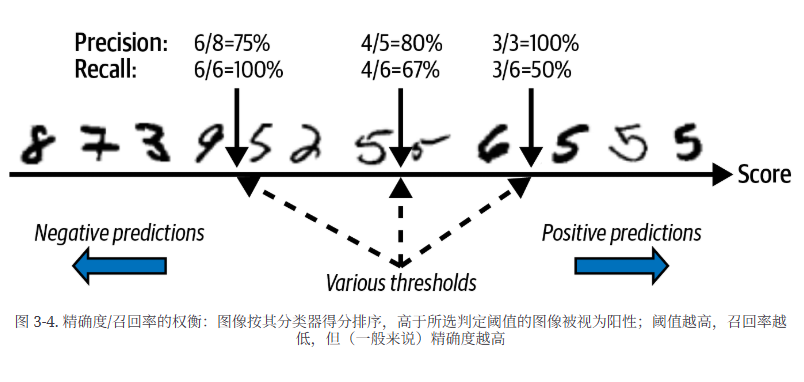

**与其调用分类器的predict() 方法，不如调用分类器的decision_function() 方法 ，该方法会返回每个实例的得分。然后，您可以使用任意阈值，根据这些分数进行预测：**

In [20]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [22]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

SGDClassifier 使用的阈值等于 0，因此前面的代码返回的结果与predict() 方法相同（即True ）。让我们提高阈值：

>>> threshold = 3000
>>> y_some_digit_pred = (y_scores > threshold)
>>> y_some_digit_pred
array([False])
这证实了提高阈值会降低召回率。图像实际上代表了一个 5，当阈值为 0 时，分类器检测到了它，但当阈值提高到 3,000 时，分类器却没有检测到它。

也就是说predict方法就是阈值为0的特殊的decision_function方法。

只不过后者可以自己调整阈值。

如何决定使用哪个阈值？一种方法是使用cross_val_predict() 函数获取训练集中所有实例的得分，但这次要指定返回决策得分而不是预测值：

In [23]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

有了这些分数后，使用precision_recall_curve() 函数 计算所有可能阈值的精确度和召回率（该函数添加了最后一个精确度为 1 和最后一个召回率为 0 的阈值，对应于无限阈值）：

In [24]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

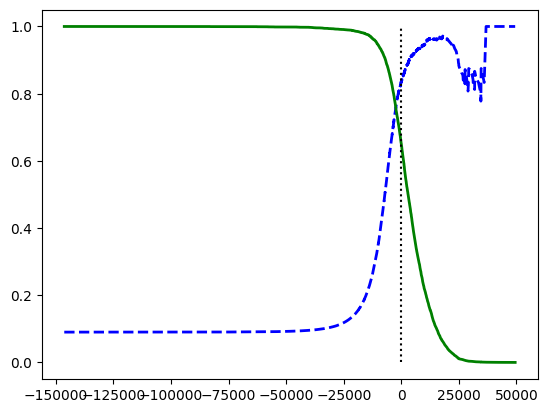

In [25]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
plt.show()

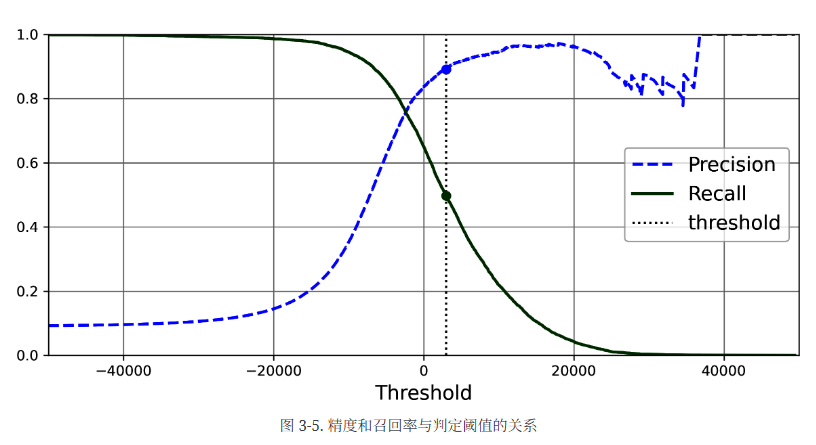

您可能会问，为什么图 3-5 中的精确度曲线 比召回率曲线更颠簸。原因是当你提高阈值时，精确度有时会下降（尽管一般情况下它会上升）。要了解原因，请回看图 3-4，注意从中心阈值开始向右移动一位数时会发生什么：精确度从 4/5（80%）下降到 3/4（75%）。另一方面，召回率只有在阈值增加时才会下降，这也解释了为什么召回率的曲线看起来很平滑。

在此阈值下，精确度接近 90%，召回率约为 50%。选择精确度/召回率折衷值的另一种方法是直接绘制精确度与召回率的对比图，如图 3-6所示（图中显示的是相同的阈值）：

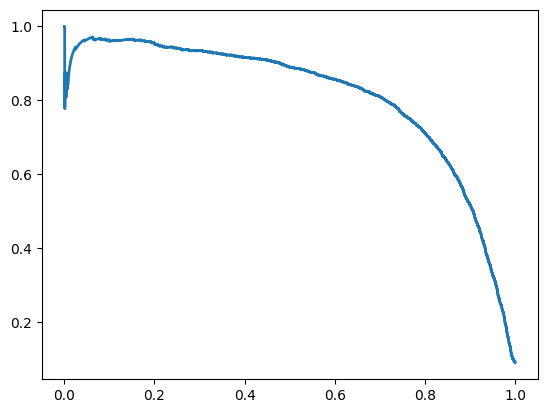

In [26]:
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.show()

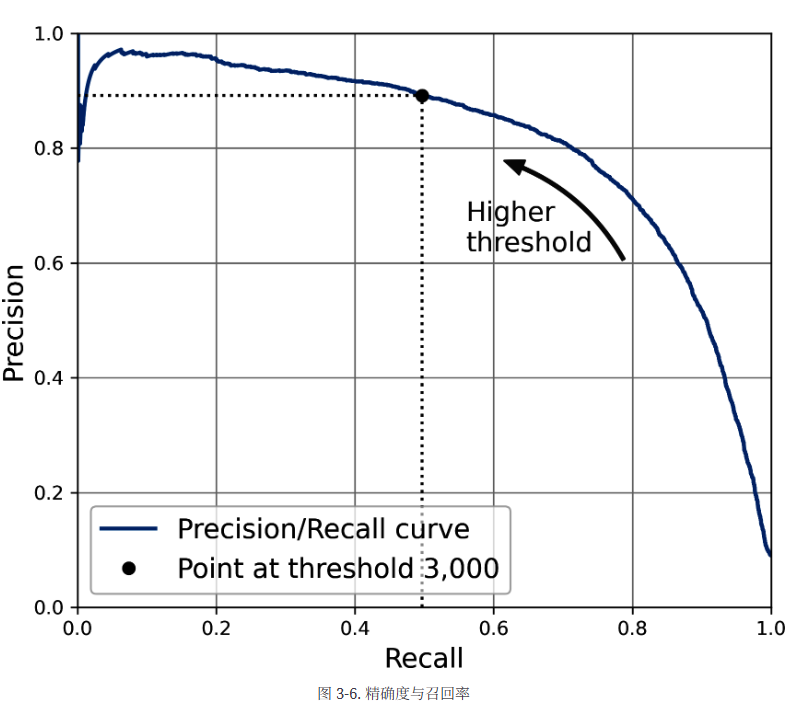

可以看出，在召回率为 80% 左右时，精确度开始急剧下降。您可能希望在精确度/召回率权衡值下降之前选择一个精确度/召回率权衡值--例如，召回率在 60% 左右时。当然，选择取决于你的项目。

假如你决定以 90% 的精确度为目标。你可以使用第一张图来找到你需要使用的阈值，但这并不是很精确。或者，您也可以寻找至少能达到 90% 精度的最低阈值。为此，您可以使用 NumPy 数组的argmax() 方法。该方法会返回最大值的第一个索引，在本例中就是指第一个True 值：

In [28]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]

In [29]:
threshold_for_90_precision

np.float64(3370.0194991439557)

要进行预测（暂时在训练集上），可以运行这段代码，而不是调用分类器的predict() 方法：

In [30]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [32]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [33]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

从 Scikit-Learn 1.5 开始，有两个新的类可以用来更方便地调整决策阈值：

FixedThresholdClassifier 类让您可以封装二元分类器，并手动设置所需的阈值。如果

*   底层分类器采用predict_proba() 方法，则阈值应为 0 到 1 之间的数值（默认值为 0.5）。否则，它应该是一个判定分数，与模型的decision_function() 输出相当（默认值为 0）。
*   TunedThresholdClassifierCV 类使用k 折交叉验证来自动查找给定指标的最佳阈值。默认情况下，它会尝试找到使模型的平衡准确率最大化的阈值：即每个类的召回率的平均值。不过，您也可以选择其他指标进行优化（有关选项的完整列表，请参阅文档）。


# **ROC 曲线**
接收者操作特性（ROC）曲线是二元分类器的另一个常用工具。它与精确度/召回率曲线非常相似，但 ROC 曲线不是绘制精确度与召回率的对比图，而是绘制真阳性率 （召回率的另一个名称）与假阳性率(FPR) 的对比图。假阳性率 （也称为下降率）是指被错误归类为阳性的阴性实例的比率。它等于 1 -真阴性率(TNR)，，TNR 是正确分类为阴性的阴性实例的比率。TNR 也称为特异性。 因此，ROC 曲线表示灵敏度 （召回率）与1 -特异性的关系。

要绘制 ROC 曲线，首先要使用roc_curve() 函数计算不同阈值下的 TPR 和 FPR ：

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

然后使用 Matplotlib 绘制 FPR 与 TPR 的对比图。下面的代码可以绘制出图 3-7 所示的曲线。要找到与 90% 精度相对应的点，我们需要查找所需阈值的索引。由于在这种情况下阈值是按递减顺序排列的，因此我们在第一行使用<= 而不是>= ：

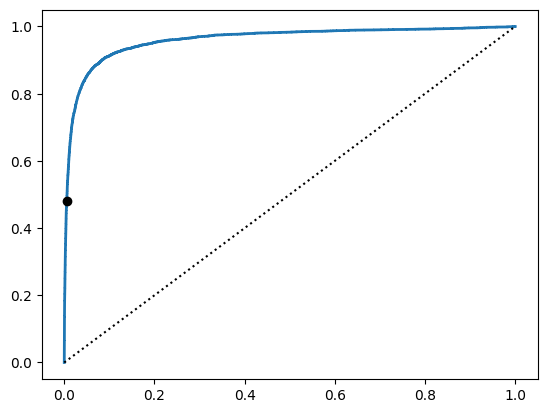

In [35]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

plt.show()

这也是一种权衡：召回率（TPR）越高，分类器产生的误报（FPR）就越多。虚线表示纯随机分类器的 ROC 曲线；好的分类器会尽可能远离该线（左上角）。

比较分类器的一种方法是测量曲线下面积（AUC）。 完美分类器的 ROC AUC 等于 1，而纯粹随机分类器的 ROC AUC 等于 0.5。Scikit-Learn 提供了一个估算 ROC AUC 的函数：

In [36]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

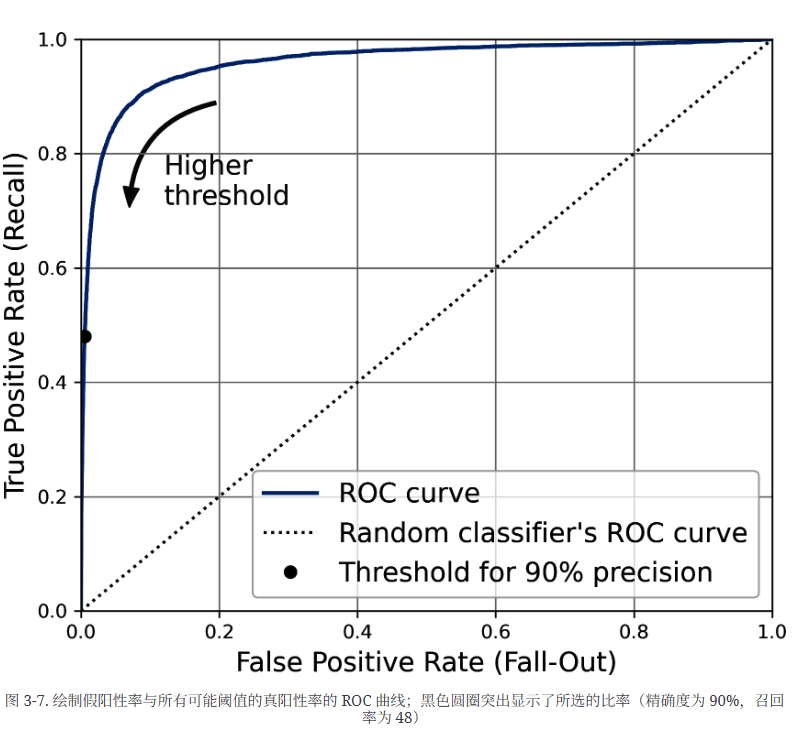

thresholds = ROC 曲线中用到的“所有候选阈值”
在 ROC 曲线（Receiver Operating Characteristic curve） 中，threshold（阈值） 是一个核心概念。

一、threshold 是什么？

简单说：

👉 threshold = 分类的“分界线”

在很多模型（比如逻辑回归、神经网络）中，模型不会直接输出类别（0 或 1），而是输出一个概率值：

𝑃
(
𝑦
=
1
∣
𝑥
)
P(y=1∣x)

然后我们需要用一个 threshold 来决定最终分类：

如果 概率 ≥ threshold → 预测为 1（正类）
如果 概率 < threshold → 预测为 0（负类）
二、举个直观例子

假设模型输出：

样本	预测概率
A	0.9
B	0.7
C	0.4
D	0.2
如果 threshold = 0.5：
A → 1
B → 1
C → 0
D → 0
如果 threshold = 0.8：
A → 1
B → 0 ❗（被改成负类）
C → 0
D → 0

👉 可以看到：threshold 会改变分类结果

三、ROC 曲线和 threshold 的关系

ROC 曲线本质上就是：

👉 把 threshold 从 1 → 0 扫一遍

每一个 threshold，都对应一个：

TPR（True Positive Rate）
FPR（False Positive Rate）
关系总结：
threshold	预测更严格还是更宽松	TPR	FPR
很高（接近1）	很严格（几乎不预测正类）	低	低
中间（0.5）	常规	中	中
很低（接近0）	很宽松（几乎全预测正类）	高	高
四、ROC 曲线是怎么画出来的？

步骤：

取所有可能的 threshold（比如从 1 → 0）
对每个 threshold：
计算 TPR
计算 FPR
把所有点画在图上 → 得到 ROC 曲线
五、关键理解（非常重要）

👉 ROC 曲线不是一个模型的“固定结果”

而是：

这个模型在“所有 threshold 下的表现”

**提示**
由于 ROC 曲线与精确度/召回率（PR）曲线非常相似 ，您可能想知道如何决定使用哪种曲线。根据经验，如果阳性类很少，或者您更关心假阳性而不是假阴性，那么您应该首选 PR 曲线。否则，请使用 ROC 曲线。例如，看了前面的 ROC 曲线（和 ROC AUC 分数），你可能会认为分类器真的很不错。但这主要是因为阳性（5 分）与阴性（非 5 分）相比很少。相比之下，PR 曲线清楚地表明分类器还有改进的余地：曲线确实可以更靠近右上角（请再看图 3-6）。

现在让我们创建一个RandomForestClassifier ，我们可以将其 PR 曲线和F1分数与SGDClassifier 进行比较：

In [37]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

precision_recall_curve() 函数 希望每个实例都有标签和分数，因此我们需要训练随机森林分类器，让它为每个实例分配分数。但RandomForestClassifier 类没有decision_function()方法（我们将在第 6 章中介绍）。

幸运的是，它有一个predict_proba() 方法，可以返回每个实例的估计类概率，我们可以直接使用正类概率作为得分，这样precision_recall_curve() 就可以工作了。4我们可以调用cross_val_​predict() 函数 ，使用交叉验证训练RandomForestClassifier ，让它预测每张图片的类别概率，如下所示：

In [38]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

让我们看看训练集中前两张图片的估计类别概率：

In [39]:
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

# **警告**
这些是估计概率，而不是实际的 概率。例如，如果您查看模型以 50% 到 60% 的估计概率分类为阳性的所有图像，其中大约 94% 的图像实际上是阳性的。因此，在这种情况下，模型估计的概率太低了，但模型也可能过于自信。sklearn.calibration 软件包中的CalibratedClassifierCV 类可以通过交叉验证来校准估计概率，使其更接近实际概率（请参阅笔记本中的代码示例）。这在某些情况下非常重要，例如医疗诊断、金融风险评估或欺诈检测。

In [40]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)

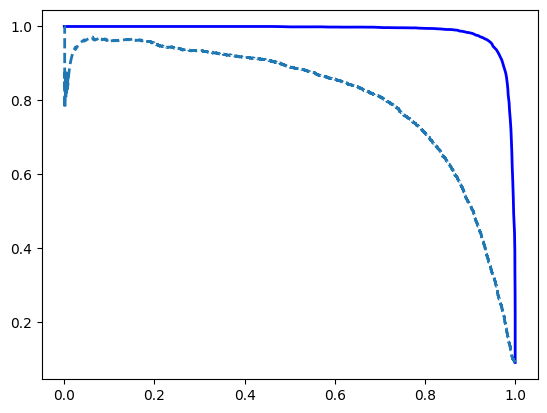

In [41]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

plt.show()

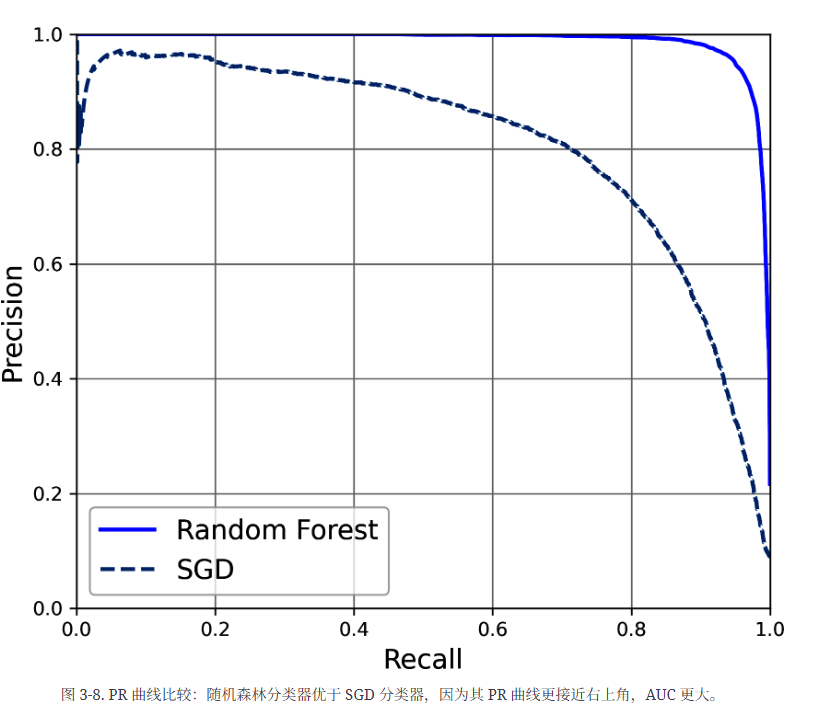

# 现在，您已经知道如何训练二元分类器、为任务选择合适的指标、使用交叉验证评估分类器、选择适合您需要的精度/召回率权衡，以及使用多种指标和曲线来比较各种模型。您已经准备好尝试检测更多信息，而不仅仅是 5。

这个问题问得很好，本质是在问三个层次：

1. **随机森林到底输出了什么？**
2. **为什么这个“概率”不是真正的概率？**
3. **为什么需要校准（calibration）？尤其在金融/医疗中**

我按这个逻辑给你讲清楚。

---

# 一、随机森林到底输出了什么“概率”？

## 1. 随机森林的结构

随机森林 = 多棵决策树（Decision Trees）

每棵树做一件事：

👉 把样本一路分裂，最终落到一个叶子节点（leaf）

---

## 2. 单棵树是怎么给“概率”的？

假设一个叶子节点里：

* 100 个训练样本
* 90 个是正类（1）
* 10 个是负类（0）

那么这棵树会说：

```text
P(y=1) = 0.9
```

👉 本质是：

> **频率 = 正类比例**

---

## 3. 随机森林的概率

随机森林会：

* 每棵树都给一个概率
* 然后取平均

[
\hat{P}(y=1 \mid x) = \frac{1}{T} \sum_{t=1}^T P_t(y=1 \mid x)
]

👉 这就是 `predict_proba()` 的来源

---

# 二、为什么这是“估计概率”，不是真正概率？

## 1. 什么是“真实概率”？

理论上：

[
P(y=1 \mid x)
]

👉 是一个“客观分布”

例如：

> 对所有特征 = x 的样本
> 实际有 94% 是正类

这才叫 **真实概率**

---

## 2. 随机森林的问题

随机森林的概率是：

👉 **基于训练数据 + 模型结构的近似**

存在几个问题：

---

### （1）叶子节点样本很少（高方差）

例如：

* 一个叶子节点只有 3 个样本
* 全是正类 → 概率 = 1.0

👉 但这明显不可靠

---

### （2）树是“硬切分”的

决策树：

* 一刀一刀切空间
* 每个区域是“离散”的

👉 导致概率是“块状”的，而不平滑

---

### （3）随机森林偏向极端概率

随机森林常见现象：

👉 **概率集中在 0 或 1**

也就是说：

* 很少输出 0.6、0.7
* 更容易输出 0.0、1.0

👉 这就叫：

> **overconfident（过于自信）**

---

## 3. 你看到的例子解释

> “预测为 50%–60% 的样本中，实际 94% 是正类”

说明：

👉 模型说：“我只有 0.55 把握”
👉 实际：“其实是 0.94 的概率”

👉 模型 **低估了概率（under-confident）**

---

# 三、什么是“校准（calibration）”？

## 1. 核心目标

让：

[
预测概率 ≈ 实际发生频率
]

---

## 2. 理想情况（完美校准）

如果模型输出：

| 预测概率 | 实际正类比例 |
| ---- | ------ |
| 0.1  | 10%    |
| 0.5  | 50%    |
| 0.9  | 90%    |

👉 这才叫 **calibrated model**

---

## 3. 校准方法（sklearn）

### CalibratedClassifierCV

它做的事情是：

👉 在模型输出之上，再套一层“校正函数”

常见方法：

---

### （1）Platt Scaling（逻辑回归）

[
p' = \frac{1}{1 + e^{-(ax + b)}}
]

👉 把原始分数重新映射

---

### （2）Isotonic Regression（非参数）

👉 用一条单调曲线拟合真实概率

---

# 四、为什么在金融/医疗中特别重要？

## 1. 医疗诊断

假设：

* 模型说：癌症概率 = 0.6

医生会理解为：

👉 “60% 风险”

但如果模型没校准：

👉 实际可能是 90%

👉 后果：**严重误判**

---

## 2. 金融风险（你这个背景很关键）

例如信用违约：

* 模型输出：违约概率 = 0.2

银行会：

* 定价（利率）
* 决定是否放贷

---

### 如果概率不准：

#### 情况1：低估风险

👉 实际 40%，模型给 20%

→ 银行亏钱 💥

---

#### 情况2：高估风险

👉 实际 10%，模型给 30%

→ 错失客户

---

👉 所以金融里要求：

> **probability must be calibrated**

---

# 五、总结（帮你形成体系）

## 1. 随机森林概率本质

👉 是：

> **叶子节点频率 + 多树平均**

---

## 2. 为什么不是“真实概率”

因为：

* 数据有限（sampling error）
* 模型结构粗糙（tree partition）
* 容易过于自信（0/1）

---

## 3. 校准在做什么

👉 学一个函数：

```text
模型输出 → 更接近真实概率
```

---

## 4. 一句话总结

👉 **随机森林给的是“统计估计”，不是“真实概率”，而 calibration 的目标是让“预测概率 ≈ 实际发生频率”。**

---

如果你愿意，我可以帮你再往前一步（这对面试很加分）：

* calibration curve（可靠性曲线）怎么画
* 为什么 logistic regression 天然更容易校准
* ROC好但概率差 vs 概率好但排序差（这个非常深）


# 多分类
二元分类器可以区分两个类别，而多类别分类器（也称为多叉分类器）可以区分两个以上的类别。

一些 Scikit-Learn 分类器（如LogisticRegression,RandomForestClassifier, 和GaussianNB ）能够原生处理多个类别。其他分类器则是严格的二进制分类器（如SGDClassifier 和SVC ）。不过，您可以使用多种策略来使用多个二进制分类器进行多类分类。

*   要创建一个能将数字图像分为 10 类（从 0 到 9）的系统，一种方法是训练 10 个二进制分类器，每个数字一个（0-检测器、1-检测器、2-检测器，依此类推）。然后，当您想对一幅图像进行分类时，您可以从每个分类器中得到该图像的判定分数，然后选择分类器输出分数最高的类别。这就是所谓的 "以一敌百"（OvR）策略，有时也称为 "以一敌众"（OvA）策略。
*   另一种策略是为每一对数字训练一个二元分类器：一个用于区分 0 和 1，另一个用于区分 0 和 2，还有一个用于区分 1 和 2，依此类推。这就是所谓的一对一（OvO）策略 。如果有N 个类别，则需要训练N×(N- 1) / 2 个分类器。对于 MNIST 问题，这意味着要训练 45 个二进制分类器！当你想对一幅图像进行分类时，你必须让图像通过所有 45 个分类器，看看哪个分类器赢得了最多的对决。OvO 的主要优势在于，每个分类器只需在训练集中包含其必须区分的两个类别的部分进行训练。

有些算法（如支持向量机分类器）会随着训练集的大小而缩小。对于这些算法，OvO 是首选，因为在小训练集中训练多个分类器比在大训练集中训练少数分类器更快。不过，对于大多数二元分类算法来说，OvR 是首选。

**Scikit-Learn 会检测你是否尝试在多分类任务中使用二元分类算法，并根据算法自动运行 OvR 或 OvO。让我们用支持向量机分类器试试看，使用sklearn.svm.SVC 类（请参阅在线章节 SVM，网址：https://homl.info）。我们只对前 2000 张图像进行训练，否则会花很长时间：**


In [42]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])  # y_train, not y_train_5

SVC(random_state=42)

我们使用从 0 到 9 的原始目标类别 (y_train) 训练SVC ，而不是使用 5 对其余目标类别 (y_train_5)。由于有 10 个类别（即多于 2 个），Scikit-Learn 使用 OvO 策略训练了 45 个二元分类器。现在，让我们对图像进行预测：

In [43]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

这段代码实际上进行了 45 次预测，每对类别预测一次，并且选择了赢得最多对决的类别。5如果调用decision_function() 方法，你会看到它为每个实例返回 10 个分数：每个类一个。根据分类器的得分，每个类得到的分数等于决斗获胜数加上或减去一个小调整（最大 ±0.33），以打破平局：

也就是45次预测给出了45个评分，但是一共只有十类，所以最终的分数是这10类在45个评分中每个类的最高分。ex:45个评分中有3个预测出是1的，但是分数不同，最高为3.79，则最终对于类别“1”返回3.79

In [45]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [46]:
class_id = some_digit_scores.argmax() #10个类别最高分--9.3
class_id

np.int64(5)

训练分类器时，分类器会在其classes_ 属性中存储目标类别列表，并按值排序。在 MNIST 的情况下，classes_ 数组中每个类的索引都很方便地与类本身相匹配（例如，索引为 5 的类恰好是类'5' ），但在一般情况下，你就没那么幸运了；你需要像这样查找类标签：

In [47]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [48]:
svm_clf.classes_[class_id]#也就是class_的索引是每个类别的分数

'5'

如果想强制 Scikit-Learn 使用单对单或单对多，可以使用OneVsOneClassifier 或OneVsRestClassifier 类。只需创建一个实例，并向其构造函数传递一个分类器（甚至不必是二进制分类器）。例如，这段代码基于SVC ，使用 OvR 策略创建了一个多分类器：

In [49]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [50]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [51]:
len(ovr_clf.estimators_)

10

在多类数据集上训练一个SGDClassifier 并用它进行预测也同样简单：

In [52]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

预测错误确实会发生！这次，Scikit-Learn 在引擎盖下使用了 OvR 策略：因为有 10 个类别，所以它训练了 10 个二元分类器。decision_function() 方法现在会为每个类别返回一个值。让我们看看 SGD 分类器为每个类别分配的分数：

In [53]:
sgd_clf.decision_function([some_digit]).round()

array([[-31893., -34420.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

可以看出，分类器对自己的预测不是很有信心：几乎所有的分数都非常负面，而第 3 类的分数为 +1,824 分，第 5 类也不差，为 -1,386 分。当然，你需要在不止一幅图像上对这个分类器进行评估。由于每个类别中的图片数量大致相同，因此准确度指标是没有问题的。像往常一样，你可以使用cross_val_score() 函数来评估模型：

In [55]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")


array([0.87365, 0.85835, 0.8689 ])

它在所有测试折叠上的准确率都超过了 85.8%。如果使用随机分类器，准确率会达到 10%，所以这个分数还不算太差，但还可以做得更好。只需缩放输入（如第 2 章所述），准确率就能提高到 89.1%以上：

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #正态分布化
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")


# 误差分析
如果 这是一个真实的项目，你现在就会按照机器学习项目清单中的步骤进行操作（见https://homl.info/checklist）。您将探索数据准备选项，尝试多个模型，筛选出最佳模型，使用GridSearchCV 对其超参数进行微调，并尽可能实现自动化。

**在此，我们假设您已经找到了一个有前途的模型，并希望找到改进它的方法。其中一种方法就是分析它所犯的错误类型。**

首先，查看***混淆矩阵***。为此，您首先需要使用cross_val_predict() 函数 进行预测；然后，您可以将标签和预测结果传递给confusion_matrix() 函数 ，就像之前所做的那样。不过，由于现在有 10 个类别而不是 2 个，混淆矩阵将包含大量数字，可能难以阅读。

混淆矩阵的彩色图更容易分析。要绘制这样的图表，请使用 ConfusionMatrixDisplay.from_predictions() 函数，如下所示：

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

这样就绘制出了图 3-9 的左图。这个混淆矩阵看起来相当不错：大多数图像都在主对角线上，这意味着它们被正确分类了。请注意，第 5 行第 5 列对角线上的单元格看起来比其他数字略暗。这可能是因为模型在 5 上犯了更多错误，也可能是因为数据集中的 5 比其他数字少。

这就是**为什么要对混淆矩阵进行归一化处理**，将每个值除以相应（真实）类别中的图像总数（即除以该行的总和）。只需设置normalize="true" 即可。我们还可以指定values_format=".0%" 参数来显示不带小数点的百分比。下面的代码将生成图 3-9 右侧的图表：

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true", values_format=".0%")
plt.show()

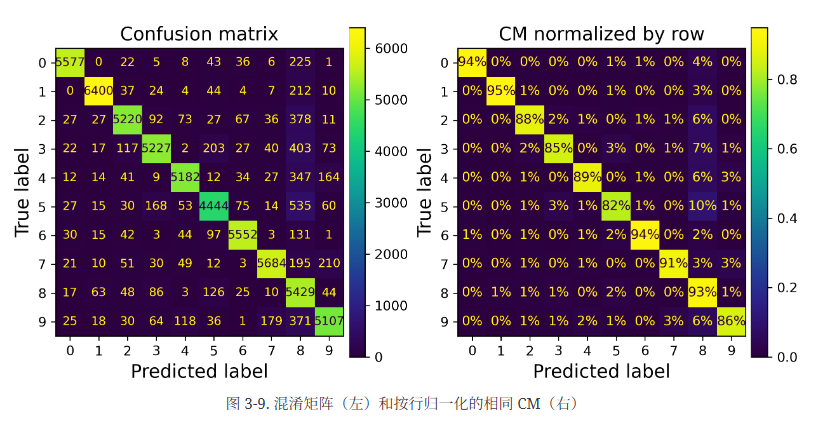

现在我们不难看出，只有 82% 的 5s 图像被正确分类。模型在处理 5 的图像时最常犯的错误是把它们错误地分类为 8：在所有 5 的图像中，有 10%的 5 被错误地分类为 8。但只有 2% 的 8 被误判为 5；混淆矩阵通常不是对称的！如果你仔细观察，就会发现很多数字都被错误地分类为 8，但从这张图上并不能一眼看出。如果想让错误更明显，可以尝试将正确预测的权重设为零。下面的代码就是这样做的，并生成了图 3-10 左侧的图表：

In [ ]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
plt.show()

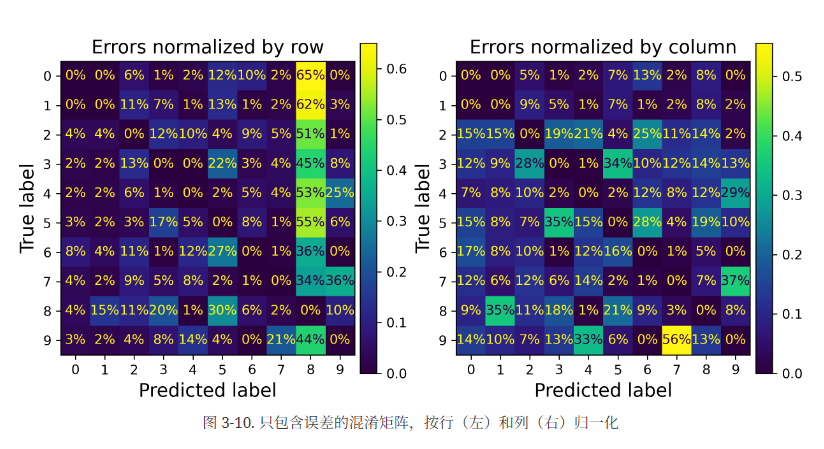

现在你可以更清楚地看到分类器的错误类型了。第 8 类这一列现在非常明亮，这证实了许多图像被错误分类为第 8 类。

**请记住，我们已经排除了正确的预测结果。**

例如，左侧网格中第 7 行第 9 列的 36% 并不意味着所有 7 的图像中有 36% 被错误分类为 9。它的意思是，**在模型对 7 的图像所做的错误分类中，有 36% 被误判为 9。**而实际上，只有 3% 的 7 图像被误判为 9，如图 3-9 右图所示。

也可以按列而不是按行对混淆矩阵进行归一化处理：如果设置normalize="pred" ，就会得到图 3-10 右侧的图表。例如，您可以看到 56% 被误判的 7 其实是 9。

**分析混淆矩阵通常能让你深入了解改进分类器的方法。通过观察这些图，您似乎应该把精力花在减少错误的 8 上。**



*   例如，你可以尝试收集更多看起来像 8 但实际上不是 8 的数字的训练数据，这样分类器就能学会将它们与真正的 8 区分开来。
*   或者，你也可以设计新的特征来帮助分类器--例如，编写一种算法来计算**闭合循环**的数量（例如，8 有两个，6 有一个，5 没有）。


*   或者，您也可以对图像进行预处理（例如，使用 Scikit-Image、Pillow 或 OpenCV），使某些模式（如闭合回路）更加突出。






分析单个错误也是深入了解分类器工作情况和失败原因的好方法。例如，让我们以混淆矩阵的形式绘制 3 和 5 的示例（图 3-11）：

In [ ]:
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

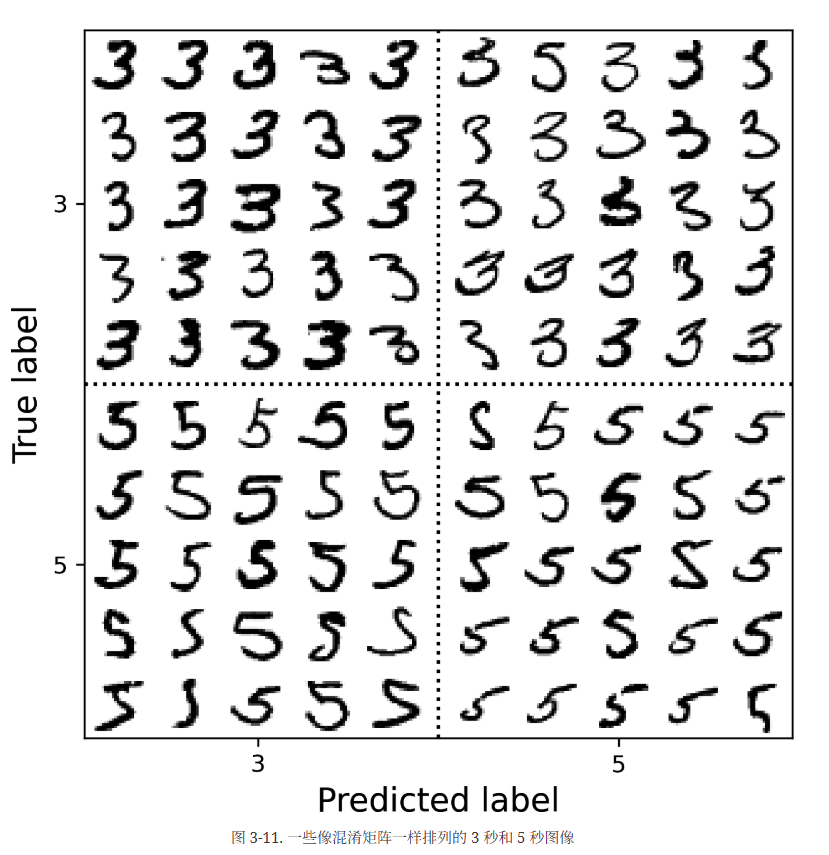

正如你所看到的，分类器弄错的一些数字（即左下角和右上角的数字块）写得非常糟糕，甚至连人都很难对它们进行分类。不过，大多数分类错误的图像在我们看来都是显而易见的错误。我们可能很难理解分类器为什么会犯这样的错误，但请记住，人脑是一个神奇的模式识别系统，我们的视觉系统会在任何信息到达我们的意识之前进行大量复杂的预处理。因此，这项任务感觉简单并不意味着它就是简单的。回想一下，我们使用了一个简单的SGDClassifier ， ，它只是一个线性模型：它所做的只是为每个像素分配一个类别权重，当它看到一个新图像时，它只是将加权像素强度相加，得到每个类别的得分。由于 3s 和 5s 只相差几个像素，这种模型很容易将它们混淆。

3s 和 5s 的主要区别在于连接顶线和底弧的小线的位置。如果您画的是 3，但连接处稍微向左移了一点，分类器可能会将其归类为 5，反之亦然。换句话说，这种分类器对图像移动和旋转相当敏感。减少 3/5 混淆的一种方法是对图像进行预处理，以确保图像居中且没有过度旋转。然而，这并不容易，因为这需要预测每幅图像的正确旋转。**一种简单得多的方法是用训练图像的轻微偏移和旋转变体来增加训练集。这将迫使模型学会对这种变化有更大的容忍度。**这就是所谓的数据增强（我们将在第 12 章中介绍；另请参阅本章末的练习 2）。

# 多标签分类
在 之前，每个实例总是只分配给一个类。但在某些情况下，你可能希望分类器为每个实例输出多个类别。

考虑一下人脸识别分类器 ：如果它在同一张图片中识别出几个人，该怎么办？它应该为识别出的每个人附加一个标签。假设分类器经过训练可以识别三张人脸：爱丽丝、鲍勃和查理。那么，当分类器看到一张爱丽丝和查理的照片时，它应该输出[True, False, True] （意思是 "爱丽丝是，鲍勃不是，查理是"）。这种能输出多个二进制标签的分类系统被称为多标签分类系统。

我们先不讨论人脸识别，我们来看一个更简单的例子，仅供参考：

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

这段代码为每个数字图像创建了一个y_multilabel 数组，其中包含两个目标标签：第一个标签表示数字是否为大数（7、8 或 9），第二个标签表示数字是否为奇数。然后，代码会创建一个支持多标签分类的KNeighborsClassifier 实例（**并非所有分类器都支持多标签分类**），并使用多目标数组训练该模型。现在你可以进行预测了，注意它输出了两个标签：

In [ ]:
knn_clf.predict([some_digit])

评估多标签分类器的方法有很多，选择正确的指标取决于你的项目。一种方法是测量每个标签的F1分数（或前面讨论过的其他二进制分类器指标），然后计算平均分数。下面的代码会计算所有标签的平均F1得分 ：

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

这种方法假设所有标签都同等重要，但实际情况可能并非如此。特别是，如果爱丽丝的图片比鲍勃或查理的图片多得多，那么分类器对爱丽丝图片的评分可能会更有权重。一个简单的方法是给每个标签赋予与其支持度（即具有该目标标签的实例数量）相等的权重。为此，只需在调用f1_score() 函数时设置average="weighted" 即可。6

如果希望使用本机不支持多标签分类的分类器（如SVC ），一种可行的策略是为每个标签训练一个模型。但是，这种策略可能难以捕捉标签之间的依赖关系。例如，一个大数字（7、8 或 9）是奇数的可能性是偶数的两倍，但 "奇数 "标签的分类器并不知道 "大 "标签的分类器预测了什么。为了解决这个问题，可以将模型组织成一个链条：当一个模型进行预测时，它会使用输入特征加上链条中排在它前面的模型的所有预测结果。

好消息是，Scikit-Learn 有一个名为ClassifierChain 的类可以做到这一点！默认情况下，它将使用真实标签进行训练，并根据每个模型在链中的位置为其提供相应的标签。但是，如果你设置了cv 超参数，它就会使用交叉验证从每个训练过的模型中获取对训练集中每个实例的 "干净"（样本外）预测，然后这些预测将用于训练链中后面的所有模型。请注意，分类器在链中的顺序可能会影响最终性能。下面的示例展示了如何使用交叉验证策略创建和训练ClassifierChain 。和前面一样，为了加快速度，我们只使用训练集中的前 2000 张图片：

In [ ]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])
chain_clf.predict([some_digit])

# 多输出分类
我们在此讨论的最后一种分类任务称为多输出多类分类（或简称多输出分类）。**它是多标签分类的一般化**，其中每个标签都可以是多类别的（即可以有两个以上的可能值）。

为了说明这一点，让我们建立一个从图像中去除噪声的系统。它将输入一张有噪声的数字图像，然后（希望）输出一张干净的数字图像，用像素强度数组表示，就像 MNIST 图像一样。请注意，**分类器的输出是多标签的（每个像素一个标签）**，**每个标签可以有多个值（像素强度范围从 0 到 255）。因此，这是一个多输出分类系统的例子。**

注意
分类和回归 之间的界限有时很模糊，比如在本例中。**可以说，预测像素强度更类似于回归，而不是分类。此外，多输出系统并不局限于分类任务；你甚至可以让系统为每个实例输出多个标签，包括类标签和值标签。**

首先，我们利用 MNIST 图像创建训练集和测试集，并使用随机数发生器的integers() 方法为其像素强度添加噪声。目标图像将是原始图像：

In [ ]:
rng = np.random.default_rng(seed=42)
noise_train = rng.integers(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise_train
noise_test = rng.integers(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise_test
y_train_mod = X_train
y_test_mod = X_test

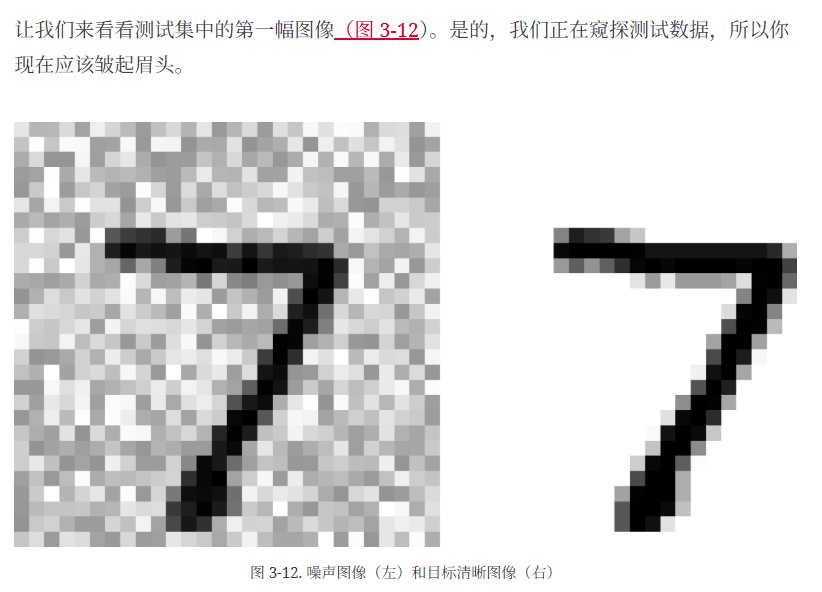

左边是噪声输入图像，右边是干净的目标图像。现在我们来训练分类器，让它清理这张图像（图 3-13）：

In [ ]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()

看起来足够接近目标！我们的分类之旅到此结束。你现在知道了如何为分类任务选择好的指标，如何选择合适的精度/召回权衡，如何比较分类器，以及如何为各种任务构建好的分类系统。在接下来的章节中，你将了解所有这些机器学习模型的实际工作原理。

# 练习
尝试为 MNIST 数据集建立一个分类器，使其在测试集上达到 97% 以上的准确率。提示：KNeighborsClassifier 对这项任务非常有效；您只需找到好的超参数值（尝试对weights 和n_neighbors 超参数进行网格搜索）。

编写一个函数，将 MNIST 图像向任意方向（左、右、上或下）移动一个像素。7然后，针对训练集中的每幅图像，创建四个移动副本（每个方向一个），并将它们添加到训练集中。最后，在扩展的训练集上训练最佳模型，并在测试集上测量其准确性。你应该会发现，你的模型现在表现得更好了！这种人为增加训练集的技术称为数据增强 或训练集扩展。

攻克泰坦尼克数据集。从Kaggle 开始是个不错的选择。或者，您也可以从https://homl.info/titanic.tgz下载数据，然后像第 2 章中处理住房数据那样解压这个压缩包。这样就会得到两个 CSV 文件：train.csv和test.csv，您可以使用pandas.read_csv() 加载这两个文件。我们的目标是训练一个分类器，它可以根据其他列预测Survived 列。

建立垃圾邮件分类器（更具挑战性的练习）：

从Apache SpamAssassin 的公共数据集中下载垃圾邮件和火腿肠的示例。

解压缩数据集，熟悉数据格式。

将数据分成训练集和测试集。

编写数据准备管道，将每封邮件转换为特征向量。您的准备管道应将电子邮件转换为（稀疏）向量，表示每个可能单词的存在或不存在。例如，如果所有邮件都只包含 "Hello"、"how"、"are"、"you "这四个单词，那么 "Hello you Hello Hello you "这封邮件就会被转换成向量 [1, 0, 0, 1]（意思是["Hello "存在，"how "不存在，"are "不存在，"you "存在]），如果你更喜欢计算每个单词的出现次数，则转换成向量 [3, 0, 0, 2]。

您可能希望在准备管道中添加超参数，以控制是否去掉邮件头、将每封电子邮件转换为小写、去掉标点符号、将所有 URL 替换为 "URL"、将所有数字替换为 "NUMBER"，甚至执行词干化 （即去掉词尾；有一些 Python 库可以做到这一点）。

最后，尝试使用多个分类器，看看能否构建一个既有高召回率又有高精度的优秀垃圾邮件分类器。

这些练习的解答可在本章笔记本的末尾找到，网址是https://homl.info/colab-p。

1默认情况下，Scikit-Learn 会将下载的数据集缓存在主目录下名为scikit_learn_data的目录中。

2 fetch_openml() 返回的数据集并不总是经过洗牌或分割。

3在某些情况下，洗牌可能不是一个好主意--例如，如果你正在处理时间序列数据（如股票市场价格或天气状况）。我们将在第 13 章探讨这个问题。

4Scikit-Learn 分类器总是有decision_function() 方法或predict_proba() 方法，有时两种方法都有。

5如果出现平局，则选择第一个类，除非您将break_ties 超参数设置为True ，在这种情况下，平局将通过decision_function() 的输出来打破。

6Scikit-Learn 还提供其他一些平均值选项和多标签分类器指标，详情请参见文档。

7可以使用scipy.ndimage.interpolation 模块中的shift() 函数。例如，shift(image, [2, 1], cval=0) 将图像向下移动两个像素，向右移动一个像素。